In [1]:
from datasets import load_dataset

# There is only one split on the hub
dataset = load_dataset("OGB/ogbg-molhiv", cache_dir="./data")

dataset = dataset.shuffle(seed=0)


/opt/miniconda3/envs/graphormer_lora/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# activate notebook autoload of files
%load_ext autoreload
%autoreload 2

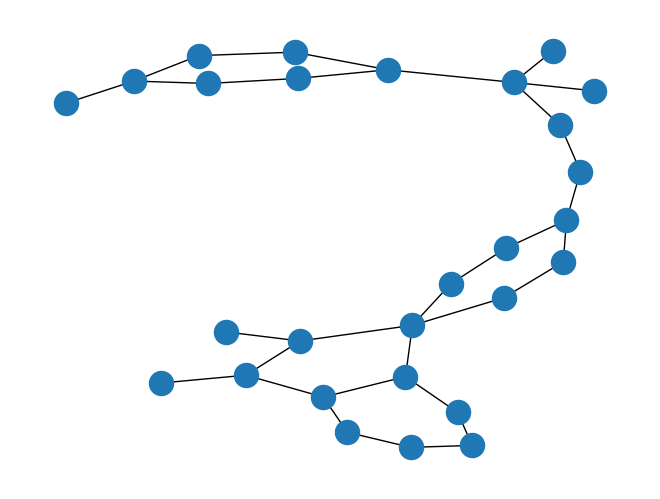

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# We want to plot the first train graph
graph = dataset["train"][0]
edges = graph["edge_index"]
num_edges = len(edges[0])
num_nodes = graph["num_nodes"]

# Conversion to networkx format
G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from([(edges[0][i], edges[1][i]) for i in range(num_edges)])

# Plot
nx.draw(G)


In [4]:
graph['num_nodes']

28

In [5]:
from transformers.models.graphormer.collating_graphormer import preprocess_item, GraphormerDataCollator

dataset_processed = dataset.map(preprocess_item, batched=False)



In [6]:
dataset_processed['train'][0].keys()

dict_keys(['edge_index', 'edge_attr', 'y', 'num_nodes', 'node_feat', 'input_nodes', 'attn_bias', 'attn_edge_type', 'spatial_pos', 'in_degree', 'out_degree', 'input_edges', 'labels'])

In [7]:
dataset_processed['train'].__len__()

32901

In [8]:
print(dataset_processed['train'][0].keys())
for key in dataset_processed['train'][0].keys():
    val = dataset_processed['train'][0][key]
    if not isinstance(val, (int, float, str)):
        print(f"{key}: {len(val)}")  
    else:
        print(f"{key}: {val}")


dict_keys(['edge_index', 'edge_attr', 'y', 'num_nodes', 'node_feat', 'input_nodes', 'attn_bias', 'attn_edge_type', 'spatial_pos', 'in_degree', 'out_degree', 'input_edges', 'labels'])
edge_index: 2
edge_attr: 62
y: 1
num_nodes: 28
node_feat: 28
input_nodes: 28
attn_bias: 29
attn_edge_type: 28
spatial_pos: 28
in_degree: 28
out_degree: 28
input_edges: 28
labels: 1


In [9]:
# from dataset import InMemoryDataset
# train_ds = dataset_processed["train"]
# train_ds = InMemoryDataset(train_ds)


In [10]:
from transformers import GraphormerForGraphClassification

model = GraphormerForGraphClassification.from_pretrained(
    "clefourrier/pcqm4mv2_graphormer_base",
    num_classes=2, # num_classes for the downstream task 
    ignore_mismatched_sizes=True,
)

/opt/miniconda3/envs/graphormer_lora/lib/python3.11/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of GraphormerForGraphClassification were not initialized from the model checkpoint at clefourrier/pcqm4mv2_graphormer_base and are newly initialized because the shapes did not match:
- classifier.classifier.weight: found shape torch.Size([1, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
model.get_memory_footprint(False) / (1024 ** 3)  # in GB

0.17761540785431862

In [ ]:
model.to("mps")

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    "graph-classification",
    logging_dir="graph-classification",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    auto_find_batch_size=True, # batch size can be changed automatically to prevent OOMs
    gradient_accumulation_steps=10,
    dataloader_num_workers=8, #1, 
    num_train_epochs=10,
    evaluation_strategy="epoch",
    logging_strategy="epoch",
    push_to_hub=False,
    dataloader_pin_memory=True,
    use_mps_device=True,
    dataloader_drop_last=True,
    seed = 42
)


In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_processed["train"],
    eval_dataset=dataset_processed["validation"],
    data_collator=GraphormerDataCollator()
)
train_results = trainer.train()

  0%|          | 0/2050 [00:00<?, ?it/s]/opt/miniconda3/envs/graphormer_lora/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Could not estimate the number of tokens of the input, floating-point operations will not be computed
  1%|▏         | 26/2050 [04:21<5:27:20,  9.70s/it]

: 